In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

plt.rcParams['font.family'] = ['Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def fast_kde(
    gdf,
    bandwidth=10_000,
    resolution=2_000,
    weight_col=None,
    study_area=None,
    padding_factor=3,
    probability_density=False,
    dtype=np.float64
):
    """
    基于二维 Gaussian Kernel 的快速栅格化 KDE。

    数学定义
    --------
    f(x, y) =
        1 / (2πh² Σwᵢ)
        × Σ wᵢ exp(
            -[(x-xᵢ)² + (y-yᵢ)²] / (2h²)
        )

    其中 h 为实际空间带宽，单位与投影坐标一致。
    对于 EPSG:4513，bandwidth=10000 即 10 km。

    Parameters
    ----------
    gdf : GeoDataFrame
        点数据，必须为 Point geometry，
        且应使用米制投影坐标系。

    bandwidth : float
        Gaussian KDE 带宽。
        单位与 CRS 坐标一致。
        例如 EPSG:4513 下：
            10000 = 10 km

    resolution : float
        KDE 输出栅格分辨率。
        单位与 CRS 坐标一致。
        例如：
            2000 = 2 km

    weight_col : str, optional
        权重字段。
        None 表示每个点权重为 1。

    study_area : GeoDataFrame, optional
        研究区。
        如果提供，则：
        1. KDE 计算范围基于研究区
        2. 最终研究区外设为 NaN

    padding_factor : float
        KDE 计算范围在研究区边界外扩多少个 bandwidth。
        默认 3 × bandwidth。
    probability_density: bool
        是否返回概率密度

    dtype : numpy dtype
        内部计算数据类型。
        默认 float64。
        大数据可改成 np.float32。

    Returns
    -------
    X : ndarray
        X 坐标网格。

    Y : ndarray
        Y 坐标网格。

    density : ndarray
        KDE 密度。
        study_area 外部为 NaN。
    """


    if gdf.empty:
        raise ValueError("gdf is empty.")

    if bandwidth <= 0:
        raise ValueError("bandwidth must be > 0.")

    if resolution <= 0:
        raise ValueError("resolution must be > 0.")

    if not np.all(gdf.geometry.geom_type == "Point"):
        raise ValueError("gdf must contain only Point geometries.")

    if gdf.crs is None:
        raise ValueError("gdf must have a projected CRS.")

    # 提取坐标
    x = gdf.geometry.x.to_numpy(dtype=dtype)
    y = gdf.geometry.y.to_numpy(dtype=dtype)

    # 权重
    if weight_col is None:
        weights = np.ones(
            len(gdf),
            dtype=dtype
        )
    else:
        weights = gdf[weight_col].to_numpy(dtype=dtype)
        if np.any(weights < 0):
            raise ValueError(
                "Weights must be non-negative."
            )

    # 去掉无效权重
    valid_weight = weights > 0
    x = x[valid_weight]
    y = y[valid_weight]
    weights = weights[valid_weight]
    total_weight = weights.sum()
    if total_weight <= 0:
        raise ValueError(
            "Total weight must be > 0."
        )


    # 确定 KDE 空间范围
    if study_area is None:
        xmin, ymin, xmax, ymax = gdf.total_bounds
    else:
        xmin, ymin, xmax, ymax = study_area.total_bounds

    # Gaussian KDE 理论上无限延伸，这里计算到 ±3h
    padding = padding_factor * bandwidth
    xmin -= padding
    xmax += padding
    ymin -= padding
    ymax += padding

    # 建立栅格
    nx = int(
        np.ceil(
            (xmax - xmin) / resolution
        )
    )
    ny = int(
        np.ceil(
            (ymax - ymin) / resolution
        )
    )
    n_cells = nx * ny

    print(f"KDE grid: {nx} × {ny}")
    print(f"Total cells: {n_cells:,}")

    if n_cells > 50_000_000:
        raise MemoryError(
            f"Grid too large: "
            f"{nx} × {ny}. "
            f"Increase resolution."
        )
    
    # 点转栅格
    ix = ((x - xmin) / resolution).astype(np.int32)
    iy = ((y - ymin) / resolution).astype(np.int32)
    valid = (
        (ix >= 0)
        & (ix < nx)
        & (iy >= 0)
        & (iy < ny)
    )
    ix = ix[valid]
    iy = iy[valid]
    weights = weights[valid]

    # 建立加权点密度栅格
    histogram = np.zeros(
        (ny, nx),
        dtype=dtype
    )
    np.add.at(
        histogram,
        (iy, ix),
        weights
    )

    # Gaussian Kernel
    # Gaussian filter 的 sigma 是像元单位
    # h = bandwidth
    # sigma_pixels = bandwidth / resolution
    sigma = bandwidth / resolution
    density = gaussian_filter(
        histogram,
        sigma=sigma,
        mode="constant",
        cval=0
    )

    # 标准二维 Gaussian KDE 归一化
    if probability_density:
        density /= (total_weight * resolution ** 2)
    else:
        density /= (resolution ** 2)

    # 网格中心坐标
    xx = xmin + (np.arange(nx) + 0.5) * resolution
    yy = ymin + (np.arange(ny) + 0.5) * resolution
    X, Y = np.meshgrid(xx, yy)

    # 研究区 mask
    if study_area is not None:

        transform = from_origin(
            xmin,
            ymax,
            resolution,
            resolution
        )

        mask = geometry_mask(
            study_area.geometry,
            out_shape=(ny, nx),
            transform=transform,
            invert=True
        )

        mask = np.flipud(mask)
        density[~mask] = np.nan
        # density[~mask | (density <= 0)] = np.nan
        density_km2 = density * 1e6  # 返回 KM 单位

    return X, Y, density_km2

## 预处理

In [3]:
df = pd.read_csv("data/data.csv")
df

,批次,名称,文物类型,时代,wgs84_lon,wgs84_lat
0,第一批,三元里平英团遗址,革命遗址及革命纪念建筑物,1841年,113.259034,23.176998
1,第一批,金田起义地址,革命遗址及革命纪念建筑物,1851年,110.080906,23.402492
2,第一批,太平天国忠王府,革命遗址及革命纪念建筑物,1860－1863年,120.630817,31.331565
3,第一批,韶山冲毛主席旧居,革命遗址及革命纪念建筑物,1893年,112.952043,27.788397
4,第一批,江孜宗山抗英遗址,革命遗址及革命纪念建筑物,1904年,89.605827,28.924014
...,...,...,...,...,...,...
5547,第八批,霍童灌溉工程,其他,隋至今,119.424375,26.859555
5548,第八批,渠江茶园,其他,明清至今,110.999826,28.095386
5549,第八批,山严 塘陂、亭塘陂水利工程,其他,宋明至今,110.356095,20.011127
5550,第八批,先市酱油酿造作坊群,其他,清至今,105.720712,28.720942


In [4]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.wgs84_lon, df.wgs84_lat),
    crs=4326
)

<Axes: >

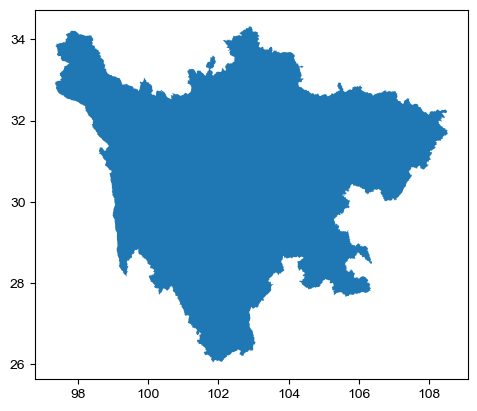

In [5]:
province = gpd.read_file("../../2024/省级/T2024年初省级.shp")
sichuan = province[province["省"]=="四川省"]
sichuan.plot()

<Axes: >

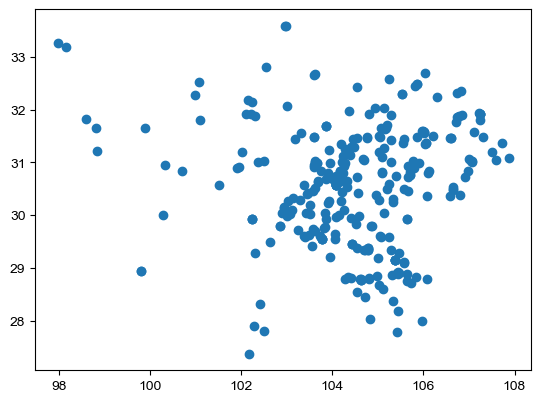

In [6]:
gdf0 = gdf.clip(sichuan)
gdf0.plot()

In [7]:
gdf0_proj = gdf0.to_crs("EPSG:4544")
sichuan_proj = sichuan.to_crs("EPSG:4544")

## 计算核密度

In [8]:
bandwidth = 10_000
resolution = 1_000

In [9]:
X, Y, density = fast_kde(
    gdf=gdf0_proj,
    bandwidth=bandwidth,
    resolution=resolution,
    study_area=sichuan_proj
)

KDE grid: 1113 × 985
Total cells: 1,096,305


In [10]:
X

array([[-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105],
       [-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105],
       [-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105],
       ...,
       [-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105],
       [-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105],
       [-246355.50701895, -245355.50701895, -244355.50701895, ...,
         863644.49298105,  864644.49298105,  865644.49298105]],
      shape=(985, 1113))

In [11]:
Y

array([[2856522.09921026, 2856522.09921026, 2856522.09921026, ...,
        2856522.09921026, 2856522.09921026, 2856522.09921026],
       [2857522.09921026, 2857522.09921026, 2857522.09921026, ...,
        2857522.09921026, 2857522.09921026, 2857522.09921026],
       [2858522.09921026, 2858522.09921026, 2858522.09921026, ...,
        2858522.09921026, 2858522.09921026, 2858522.09921026],
       ...,
       [3838522.09921026, 3838522.09921026, 3838522.09921026, ...,
        3838522.09921026, 3838522.09921026, 3838522.09921026],
       [3839522.09921026, 3839522.09921026, 3839522.09921026, ...,
        3839522.09921026, 3839522.09921026, 3839522.09921026],
       [3840522.09921026, 3840522.09921026, 3840522.09921026, ...,
        3840522.09921026, 3840522.09921026, 3840522.09921026]],
      shape=(985, 1113))

In [12]:
density

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(985, 1113))

## 可视化

In [13]:
def plot_(cmap, fig_name):
    fig, ax = plt.subplots(figsize=(8, 8))

    # KDE 填色
    cf = ax.contourf(
        X,
        Y,
        density,
        levels=levels,
        cmap=cmap,
        extend="max"
    )
    # KDE 等值线
    cs = ax.contour(
        X,
        Y,
        density,
        levels=levels[2::2],
        colors="black",
        linewidths=0.45,
        alpha=0.35
    )

    # 边界
    sichuan_proj.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        zorder=1
    )
    #  KDE 点
    gdf0_proj.plot(
        ax=ax,
        markersize=5,
        color="black",
        alpha=0.15,
        linewidth=0,
        zorder=8
    )


    # cbar
    cbar = fig.colorbar(
        cf,
        ax=ax,
        fraction=0.035,
        pad=0.025,
        shrink=0.82
    )
    cbar.set_label(
        "Kernel density",
        fontsize=11,
        labelpad=8
    )
    cbar.ax.tick_params(
        labelsize=9,
        width=0.6,
        length=3
    )

    ax.axis("off")
    ax.set_aspect("equal")
    ax.set_title(
        "Gaussian KDE\n"
        f"Bandwidth={bandwidth / 1000:.0f}km, N={len(gdf0_proj)}",
        fontsize=12,
        pad=10
    )

    plt.savefig(f"fig/{fig_name}.png", dpi=400, bbox_inches='tight')
    plt.show()

In [14]:
colors = [
    "#F6F8F5",
    "#E7ECE4",
    "#D5DED1",
    "#C0CEC0",
    "#A7BAAA",
    "#8FA696",
    "#718C7C",
    "#536F60",
    "#365445",
]

cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

# 使用分位数控制极端高值
vmin = np.nanpercentile(density, 2)
vmax = np.nanpercentile(density, 99)
levels = np.linspace(
    vmin,
    vmax,
    16  # KDE 填色等级数量
)

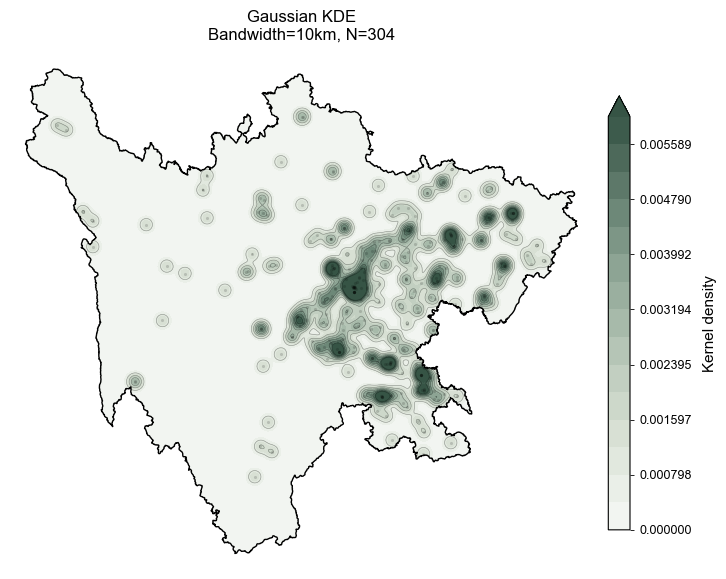

In [15]:
plot_(
    cmap,
    "fig1"
)

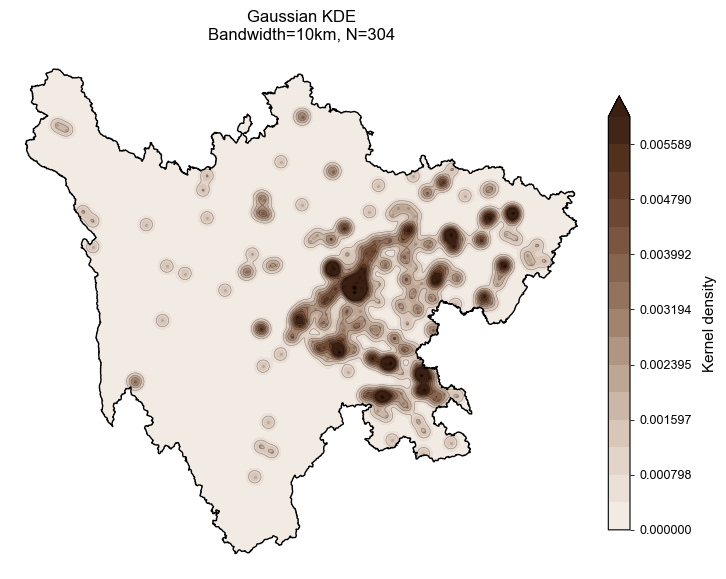

In [16]:
colors = [
    "#F6F0EA",
    "#E8DCD2",
    "#D5C3B5",
    "#BCA392",
    "#A28370",
    "#89664F",
    "#704B37",
    "#573421",
    "#3A2013",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig2"
)

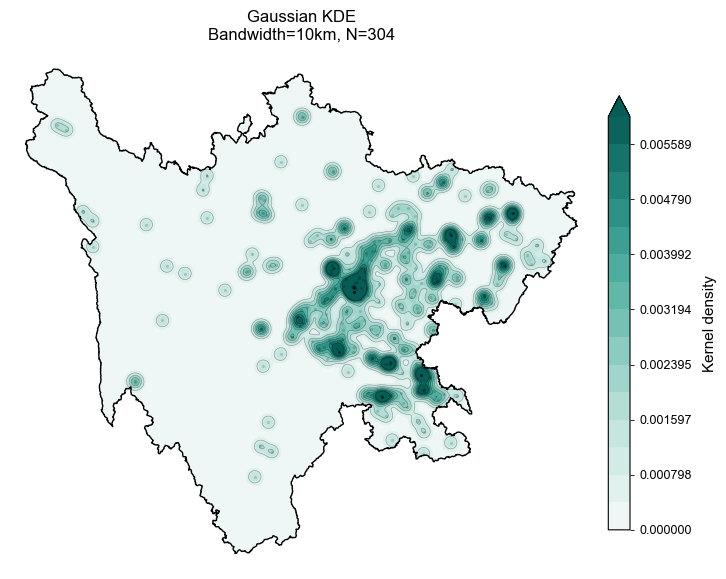

In [17]:
colors = [
    "#F4FAF9",
    "#DCEFEB",
    "#C1E3DE",
    "#9ED3CA",
    "#77C1B4",
    "#50AFA0",
    "#319589",
    "#19796F",
    "#075C55",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig3"
)

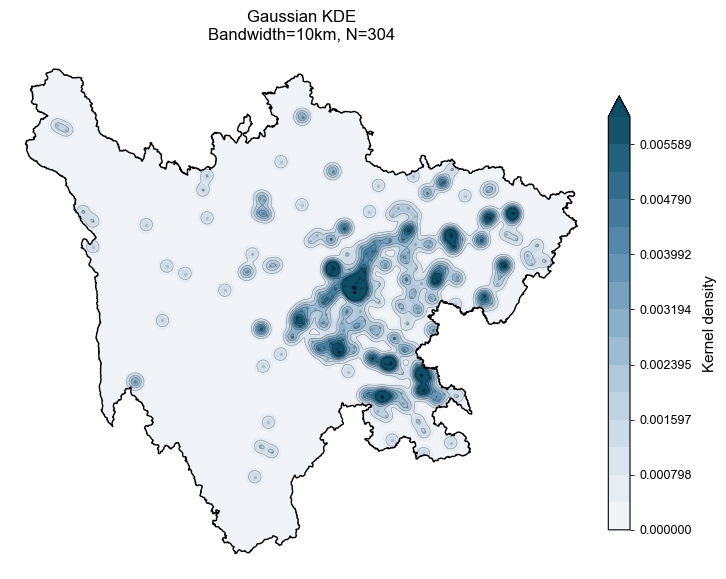

In [18]:
colors = [
    "#F5F8FB",
    "#E2EAF2",
    "#CBD9E6",
    "#AEC6D8",
    "#8BAFC8",
    "#6797B7",
    "#467F9F",
    "#286681",
    "#0E4D66",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig4"
)

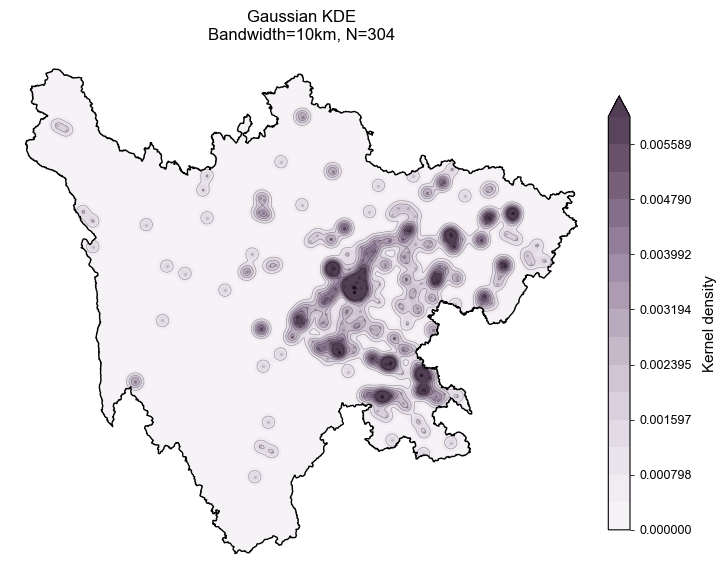

In [19]:
colors = [
    "#F9F7FA",
    "#EEE9F0",
    "#E0D8E4",
    "#CEC3D3",
    "#BAAABD",
    "#A28FA9",
    "#88738F",
    "#6D586F",
    "#523E54",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig5"
)

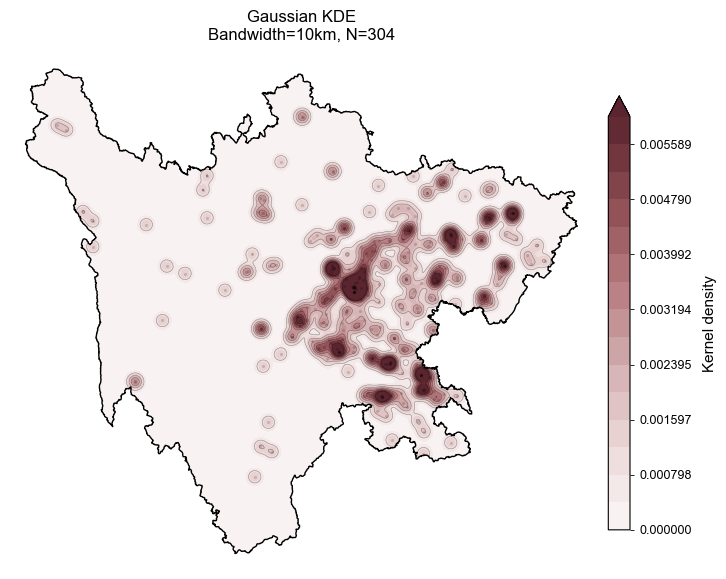

In [20]:
colors = [
    "#FCF7F7",
    "#F2E5E5",
    "#E6CECE",
    "#D7B3B4",
    "#C49396",
    "#B17478",
    "#96565C",
    "#783B43",
    "#5A252F",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig6"
)

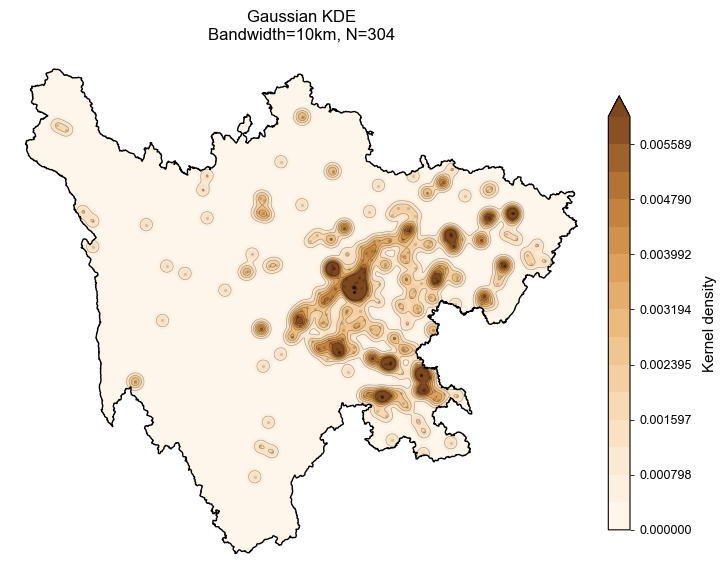

In [21]:
colors = [
    "#FFF9F1",
    "#FCEEDB",
    "#F9E0C0",
    "#F3CEA0",
    "#EABB7D",
    "#DEA25C",
    "#C8873F",
    "#A9692F",
    "#7D481F",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig7"
)

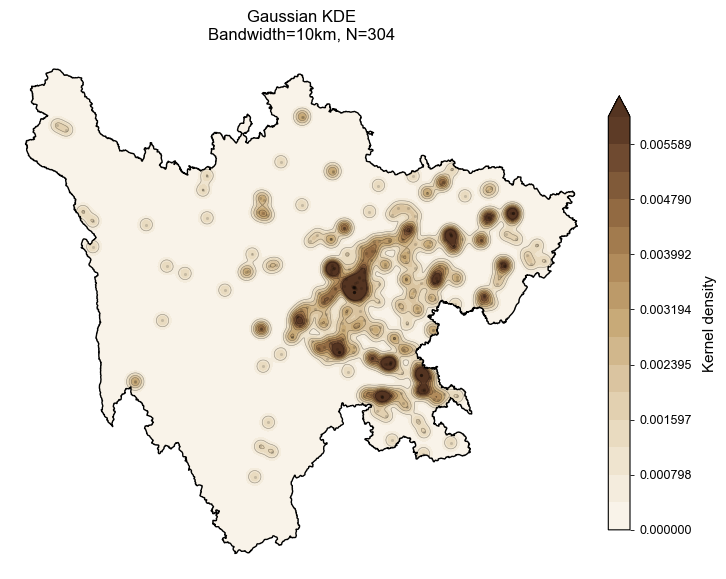

In [22]:
colors = [
    "#FBF7EF",
    "#F2E9D8",
    "#E7D8BC",
    "#D9C29D",
    "#C8AA78",
    "#B38D5D",
    "#976F45",
    "#765034",
    "#543421",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig8"
)

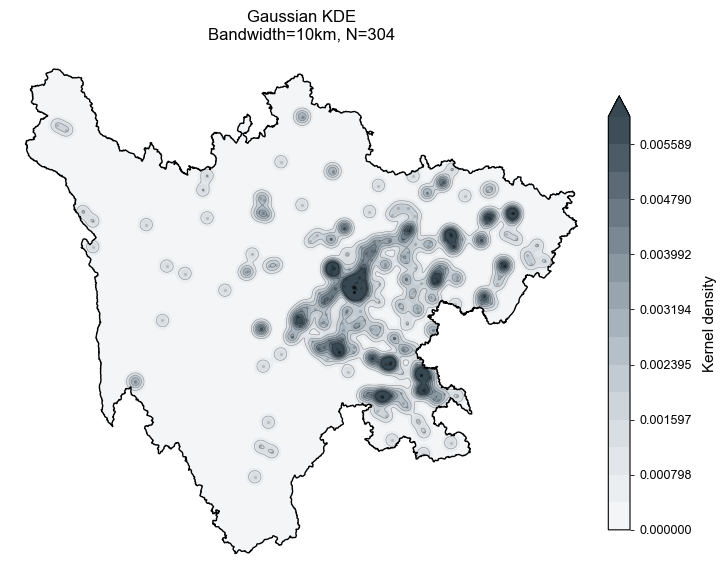

In [23]:
colors = [
    "#F7F8F9",
    "#E8EBEE",
    "#D6DCE1",
    "#C0C9D0",
    "#A7B3BC",
    "#8B99A3",
    "#6E7D88",
    "#52616D",
    "#374852",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig9"
)

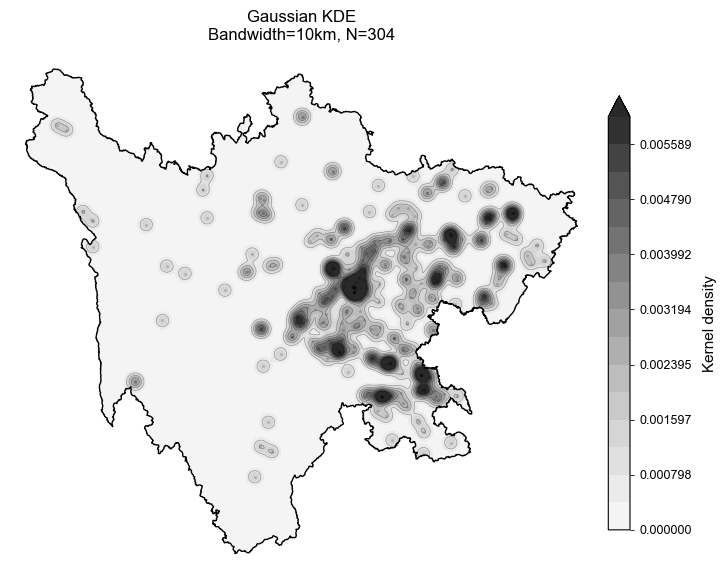

In [24]:
colors = [
    "#F8F8F8",
    "#E7E7E7",
    "#D2D2D2",
    "#BBBBBB",
    "#A1A1A1",
    "#858585",
    "#686868",
    "#4A4A4A",
    "#292929",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig10"
)

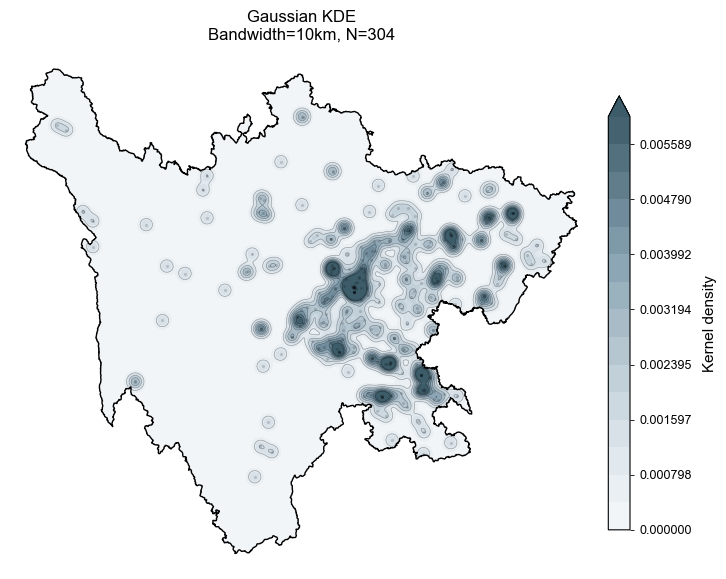

In [25]:
colors = [
    "#F6F8FA",
    "#E7EDF1",
    "#D5DFE6",
    "#C0CFD9",
    "#A8BBC7",
    "#8FA8B7",
    "#748F9F",
    "#587582",
    "#3D5C69",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig11"
)

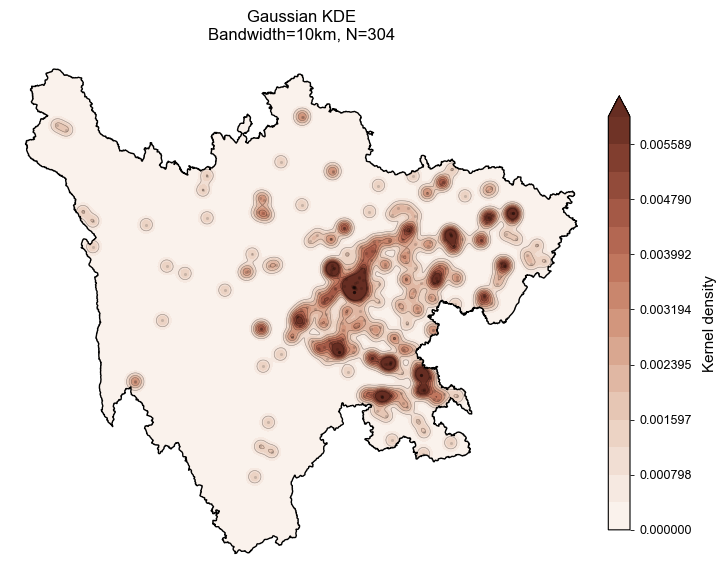

In [26]:
colors = [
    "#FCF6F2",
    "#F4E5DC",
    "#EBD0C0",
    "#DFB5A0",
    "#D2967D",
    "#C27860",
    "#A95D49",
    "#884333",
    "#662D22",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig12"
)

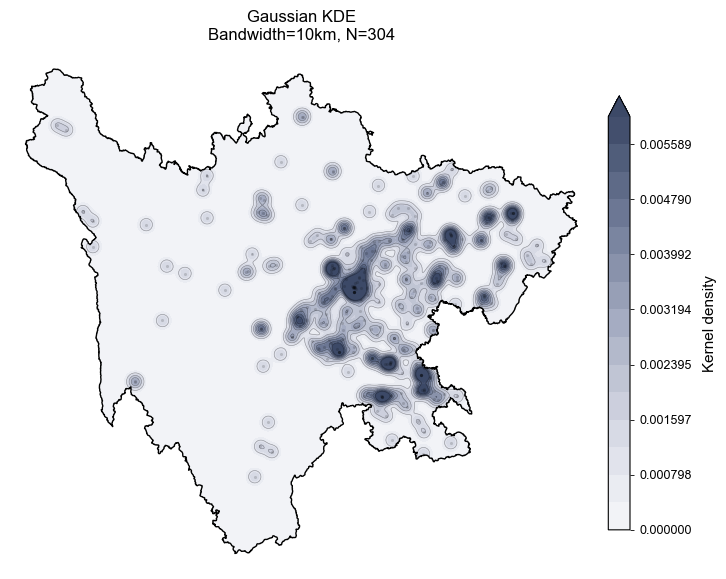

In [27]:
colors = [
    "#F6F7FA",
    "#E7E9F0",
    "#D4D7E3",
    "#BEC3D3",
    "#A5ACC2",
    "#8B94AD",
    "#707B98",
    "#56627F",
    "#3C4967",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig13"
)

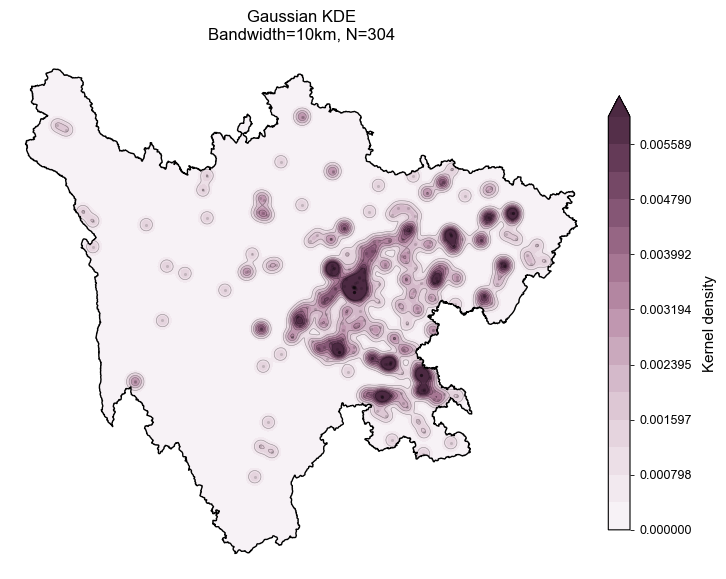

In [28]:
colors = [
    "#FAF6F9",
    "#F0E5EC",
    "#E3D1DC",
    "#D3B7C8",
    "#C098B0",
    "#A97895",
    "#8A5A79",
    "#6B3F5D",
    "#4C2942",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig14"
)

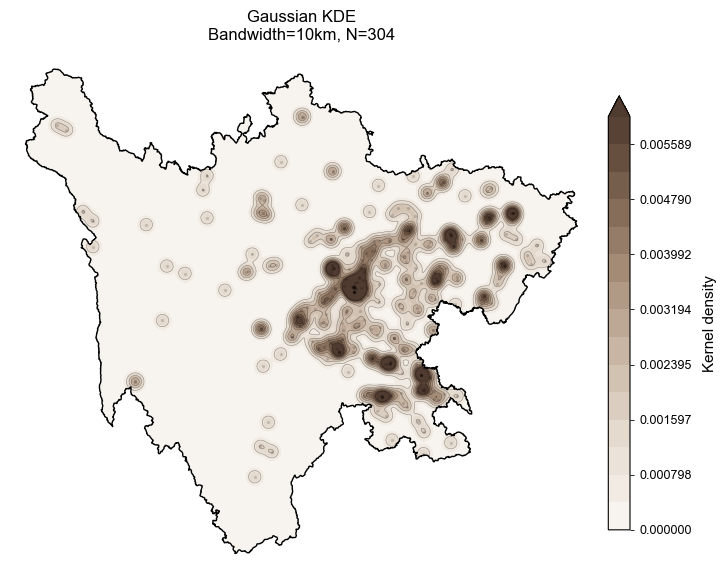

In [29]:
colors = [
    "#FAF7F3",
    "#EFE8E0",
    "#E2D7CB",
    "#D1C0B0",
    "#BDA795",
    "#A58D78",
    "#8A715E",
    "#6D5545",
    "#503B30",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig15"
)

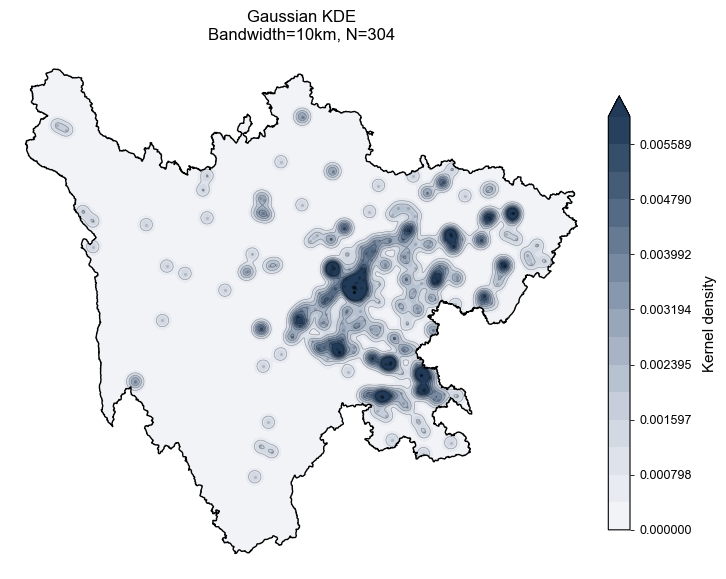

In [30]:
colors = [
    "#F5F7FA",
    "#E4E8EF",
    "#CFD6E1",
    "#B5C0D0",
    "#98A6BA",
    "#798BA3",
    "#5A6F89",
    "#3B536F",
    "#203A57",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig16"
)

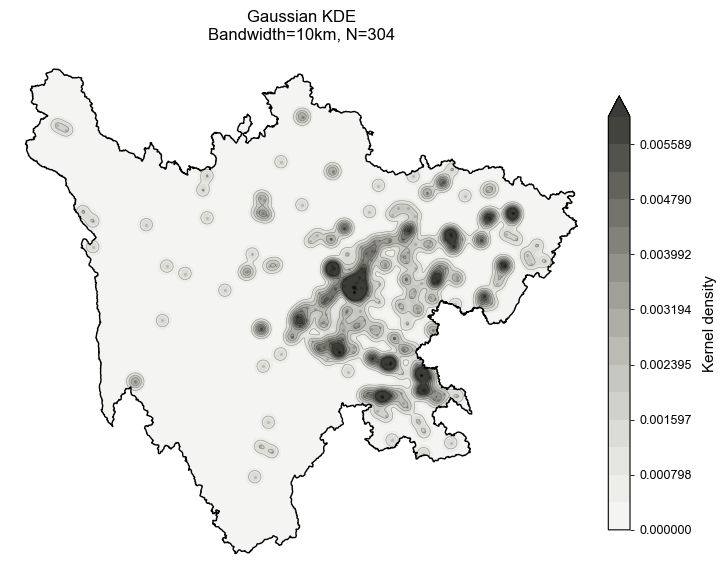

In [31]:
colors = [
    "#F8F8F7",
    "#EAEAE7",
    "#D9D9D4",
    "#C5C5BF",
    "#AEAEA7",
    "#94948C",
    "#777770",
    "#595953",
    "#3B3B37",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig17"
)

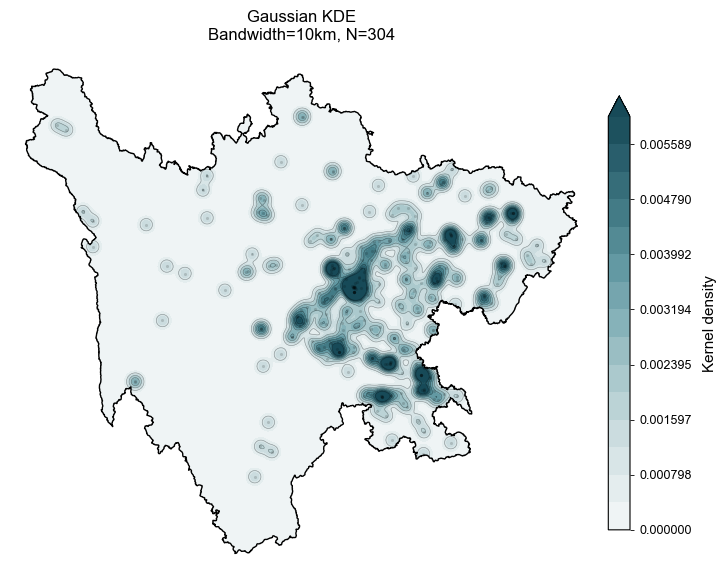

In [32]:
colors = [
    "#F4F8F8",
    "#E0EAEB",
    "#C7DADD",
    "#A9C8CC",
    "#87B2B9",
    "#669BA5",
    "#477F8A",
    "#2E6471",
    "#174A58",
]
cmap = LinearSegmentedColormap.from_list(
    name="my_cmap",
    colors=colors,
    N=256
)

plot_(
    cmap,
    "fig18"
)